In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir = base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'
train_pn = [
    train_pneumonia_dir + "{}".format(i)
    for i in os.listdir(train_pneumonia_dir)
]

train_normal = [
    train_normal_dir + "{}".format(i)
    for i in os.listdir(train_normal_dir)
]

test_pn = [
    test_pneumonia_dir + "{}".format(i)
    for i in os.listdir(test_pneumonia_dir)
]

test_normal = [
    test_normal_dir + "{}".format(i)
    for i in os.listdir(test_normal_dir)
]


In [10]:
img_size = 224

X_train = []
Y_train = []

X_test = []
Y_test = []

for image_path in train_normal:

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img, (img_size, img_size))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype('float32') / 255.0

    X_train.append(img)

    Y_train.append(0)

for image_path in train_pn:

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img, (img_size, img_size))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype('float32') / 255.0

    X_train.append(img)

    Y_train.append(1)

for image_path in test_normal:

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img, (img_size, img_size))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype('float32') / 255.0

    X_test.append(img)

    Y_test.append(0)


# PNEUMONIA IMAGES
for image_path in test_pn:

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img, (img_size, img_size))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype('float32') / 255.0

    X_test.append(img)

    Y_test.append(1)

X_train = np.array(X_train)

Y_train = np.array(Y_train)

X_test = np.array(X_test)

Y_test = np.array(Y_test)

print("Train Shape :", X_train.shape)

print("Test Shape :", X_test.shape)



Train Shape : (5216, 224, 224, 3)
Test Shape : (624, 224, 224, 3)


In [11]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
svm_accuracies = []

cnn_accuracies = []

def calculate_metrics(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    TP = cm[1,1]

    TN = cm[0,0]

    FP = cm[0,1]

    FN = cm[1,0]

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    return accuracy, f1, sensitivity, specificity

In [12]:
print("\n========================")
print("SVM RESULTS")
print("========================")

for size in train_sizes:

    print(f"\nTraining with {int(size*100)}% data")

    X_sub, _, Y_sub, _ = train_test_split(
        X_train,
        Y_train,
        train_size=size,
        stratify=Y_train,
        random_state=42
    )

    X_sub_flat = X_sub.reshape(len(X_sub), -1)

    X_test_flat = X_test.reshape(len(X_test), -1)

    svm_model = SVC(kernel='linear')

    svm_model.fit(X_sub_flat, Y_sub)

    y_pred = svm_model.predict(X_test_flat)

    accuracy, f1, sensitivity, specificity = calculate_metrics(
        Y_test,
        y_pred
    )

    svm_accuracies.append(accuracy)

    print("Accuracy :", accuracy)

    print("F1-score :", f1)

    print("Sensitivity :", sensitivity)

    print("Specificity :", specificity)




SVM RESULTS

Training with 20% data
Accuracy : 0.7467948717948718
F1-score : 0.8297413793103449
Sensitivity : 0.9871794871794872
Specificity : 0.34615384615384615

Training with 40% data
Accuracy : 0.7676282051282052
F1-score : 0.8418756815703381
Sensitivity : 0.9897435897435898
Specificity : 0.3974358974358974

Training with 60% data
Accuracy : 0.75
F1-score : 0.8311688311688312
Sensitivity : 0.9846153846153847
Specificity : 0.358974358974359

Training with 80% data
Accuracy : 0.7451923076923077
F1-score : 0.8284789644012945
Sensitivity : 0.9846153846153847
Specificity : 0.34615384615384615


In [14]:
print("\n========================")
print("CNN RESULTS")
print("========================")

for size in train_sizes:

    print(f"\nTraining with {int(size*100)}% data")

    # Select subset of training data
    X_sub, _, Y_sub, _ = train_test_split(
        X_train,
        Y_train,
        train_size=size,
        stratify=Y_train,
        random_state=42
    )

    # One-hot encoding
    Y_sub_cat = to_categorical(Y_sub, num_classes=2)

    Y_test_cat = to_categorical(Y_test, num_classes=2)

    # LOAD PRETRAINED MOBILENETV2
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # FREEZE PRETRAINED LAYERS
    for layer in base_model.layers:
        layer.trainable = False

    # ADD CUSTOM CLASSIFIER
    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.5)(x)

    predictions = Dense(2, activation='softmax')(x)

    # FINAL MODEL
    model = Model(
        inputs=base_model.input,
        outputs=predictions
    )

    # COMPILE MODEL
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # SAVE BEST MODEL
    checkpoint = ModelCheckpoint(
        f'best_model_{int(size*100)}.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    # TRAIN MODEL
    history = model.fit(
        X_sub,
        Y_sub_cat,
        validation_data=(X_test, Y_test_cat),
        epochs=20,
        batch_size=32,
        callbacks=[checkpoint],
        verbose=1
    )

    # PREDICTIONS
    predictions = model.predict(X_test)

    y_pred = np.argmax(predictions, axis=1)

    # METRICS
    accuracy, f1, sensitivity, specificity = calculate_metrics(
        Y_test,
        y_pred
    )

    cnn_accuracies.append(accuracy)

    print("Accuracy :", accuracy)

    print("F1-score :", f1)

    print("Sensitivity :", sensitivity)

    print("Specificity :", specificity)



CNN RESULTS

Training with 20% data
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6668 - loss: 0.7876
Epoch 1: val_loss improved from inf to 0.78139, saving model to best_model_20.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 459ms/step - accuracy: 0.6671 - loss: 0.7860 - val_accuracy: 0.6234 - val_loss: 0.7814
Epoch 2/20
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7127 - loss: 0.6282
Epoch 2: val_loss improved from 0.78139 to 0.70246, saving model to best_model_20.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7122 - loss: 0.6291 - val_accuracy: 0.6314 - val_loss: 0.7025
Epoch 3/20
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7353 - loss: 0.5416
Epoch 3: val_loss improved from 0.70246 to 0.66240, saving model to best_model_20.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7342 - loss: 0.5444 - val_accuracy: 0.6394 - val_loss: 0.6624
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7606 - loss: 0.5030
Epoch 4: val

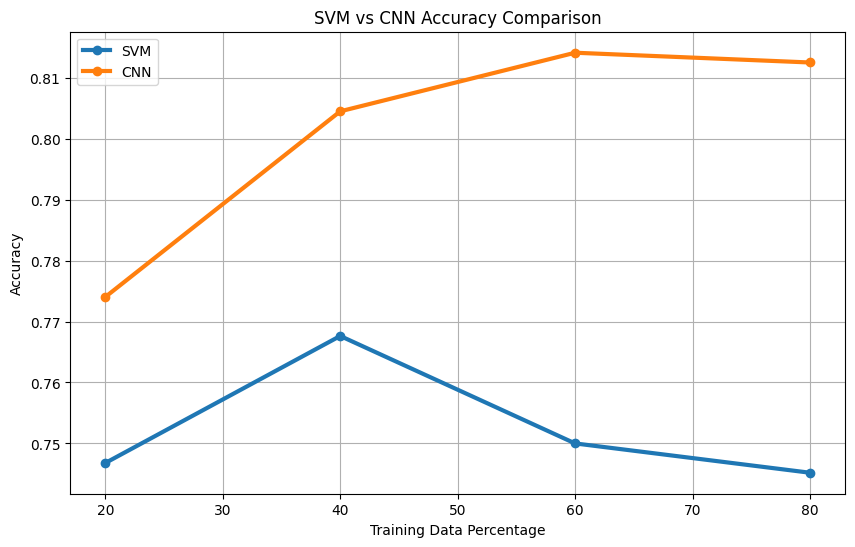

In [16]:
sizes = [20, 40, 60, 80]

plt.figure(figsize=(10,6))

plt.plot(
    sizes,
    svm_accuracies,
    marker='o',
    linewidth=3,
    label='SVM'
)

plt.plot(
    sizes,
    cnn_accuracies,
    marker='o',
    linewidth=3,
    label='CNN'
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("SVM vs CNN Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()

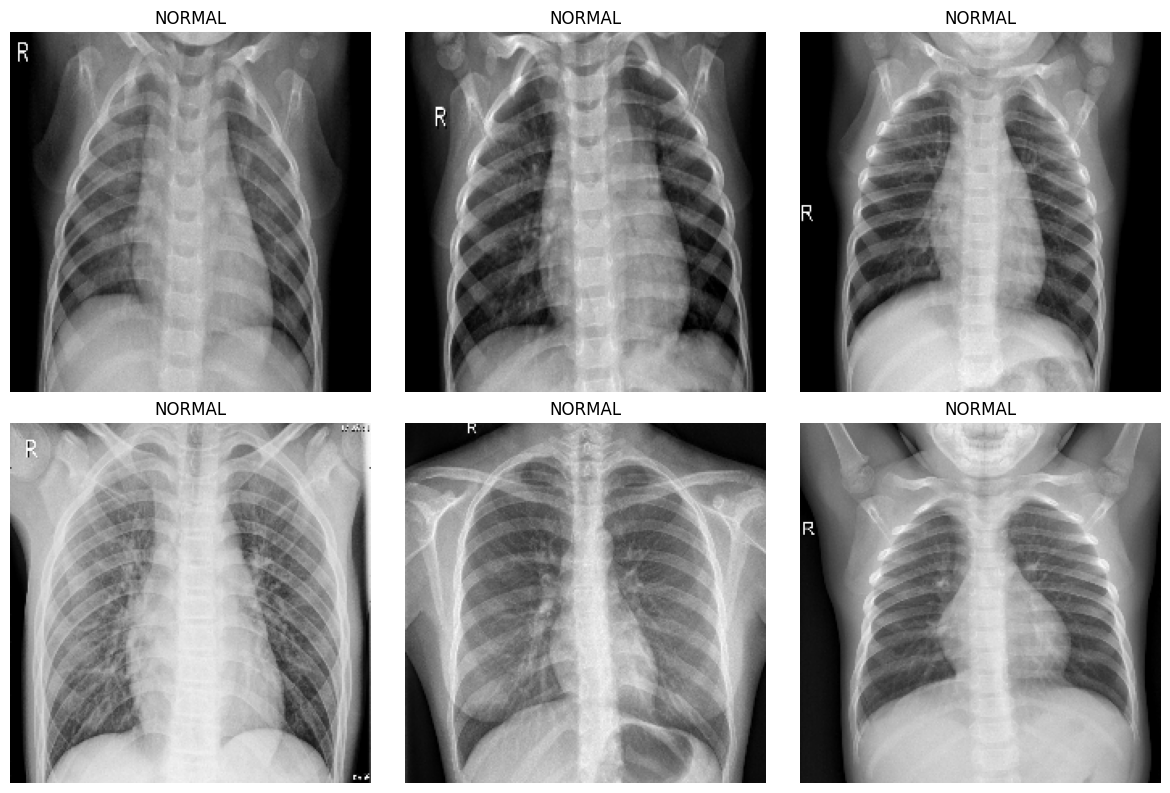

In [17]:
class_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    plt.title(class_names[Y_test[i]])

    plt.axis('off')

plt.tight_layout()

plt.show()